# Week 3 Internship Project: Unsupervised Learning & Clustering Analysis
## Customer Behavioral Segmentation in E-Commerce
**Course / Track**: Advanced Machine Learning & Data Science Internship  
**Topic**: Unsupervised Learning, K-Means Clustering, Agglomerative Hierarchical Clustering, Dimensionality Reduction, and Customer Profiling  
**Author**: *[Student Name]*  
**Date**: September 2026  

---
### Executive Abstract
This analytical notebook implements an end-to-end unsupervised learning solution to discover latent customer behavioral archetypes in transactional retail data. Rather than treating clustering as an arbitrary mechanical execution of distance formulas, this analysis establishes a complete, defensible analytical chain:
1. Ingesting and auditing 541,909 raw transactions from the **UCI Online Retail Dataset**.
2. Engineering customer-level behavioral dimensions (Recency, Frequency, Monetary value, Average Order Value, Basket Size, Product Diversity, and Tenure).
3. Mitigating severe positive power-law skewness through variance-stabilizing logarithmic transformations ($y = \log(1 + x)$).
4. Standardizing the feature space to preserve isotropic Euclidean geometry.
5. Evaluating candidate cluster counts ($k \in [2, 7]$) across four rigorous internal validation criteria (Within-Cluster Sum of Squares Elbow, Silhouette Score, Calinski-Harabasz Index, and Davies-Bouldin Index).
6. Conducting bootstrap stability testing with the Adjusted Rand Index (ARI) and comparing K-Means against Agglomerative Hierarchical Clustering.
7. Visualizing multi-dimensional cluster geometries using 2D Principal Component Analysis (PCA) and t-SNE manifolds.
8. Profiling each discovered segment parametrically and non-parametrically to formulate actionable e-commerce marketing, retention, and operational strategies.


## 1. Project Objective & Scope

The primary objective of this project is to partition an unlabelled customer population into homogeneous, statistically distinct, and operationally meaningful clusters.

Specifically, the workflow seeks to:
- Formulate a clean customer-level feature representation from raw transactional event logs.
- Address severe heavy-tailed distributions and scaling imbalances that distort distance-based clustering algorithms.
- Empirically justify the choice of algorithm (K-Means vs. Agglomerative Hierarchical Clustering) and parameter configurations ($k$).
- Statistically profile and semantically interpret each discovered cluster without assuming causal relationships.
- Translate quantitative cluster characteristics into defensible business strategies for customer lifetime value (CLV) optimization.


## 2. Dataset Source & Context

The analysis utilizes the **Online Retail Dataset** hosted by the **UCI Machine Learning Repository** (Dataset ID: 352).
- **Primary Reference**: Chen, D., Sain, S. L., & Guo, K. (2012). *Data mining for the online retail industry: A case study of RFM model-based customer segmentation using data mining*. Journal of Database Marketing & Customer Strategy Management, 19(3), 197–208.
- **Domain**: Non-store online retail firm based in the United Kingdom.
- **Product Scope**: Unique all-occasion giftware (predominantly wholesale and individual retail buyers).
- **Time Window**: 01/12/2010 to 09/12/2011 (approx. 12 calendar months).
- **Scale**: 541,909 transactional records across 38 countries.
- **License**: Creative Commons Attribution 4.0 International (CC BY 4.0).


## 3. Environment Setup & Library Imports

We import standard numerical, data manipulation, statistical, clustering, and visualization libraries. All random seeds are fixed (`random_state=42`) to guarantee deterministic reproducibility.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure project src modules are importable
sys.path.insert(0, os.path.abspath(".."))

from src.data_loading import load_raw_data
from src.preprocessing import (
    clean_transactions,
    engineer_customer_features,
    prepare_clustering_matrix,
    CORE_FEATURES
)
from src.clustering import (
    train_kmeans,
    train_hierarchical,
    compute_hierarchical_linkage,
    compute_pca,
    compute_tsne
)
from src.evaluation import (
    evaluate_cluster_range,
    evaluate_hierarchical_range,
    evaluate_stability,
    compare_algorithms
)

# Plotting configuration
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "figure.dpi": 150,
    "savefig.dpi": 300
})
PALETTE = ["#2E86AB", "#D9534F", "#3BB273", "#E09F3E"]
print("All analytical libraries loaded successfully.")


All analytical libraries loaded successfully.


## 4. Data Loading & Ingestion

We load the raw transactional data using our automated pipeline in `src.data_loading`. If the dataset has not been cached locally, it is downloaded from the UCI repository and cached for high-speed reproducibility.


In [2]:
df_raw = load_raw_data(base_dir="..")
print(f"Dataset Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head(5)


[INFO] Loading raw transactions from /home/hamasaki/Documents/Internship/Week_3/data/raw/online_retail.csv ...
[INFO] Successfully loaded 541,909 transactions in 0.34s.
Dataset Shape: 541,909 rows x 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 5. Data Understanding & Quality Assessment

A rigorous data-quality audit is essential prior to unsupervised modeling. We examine missing values, duplicate entries, cancellations, and numeric ranges.


In [3]:
# Missing Value Analysis
missing_summary = pd.DataFrame({
    'Missing_Count': df_raw.isnull().sum(),
    'Missing_Percentage': (df_raw.isnull().mean() * 100).round(2)
})
print("--- Missing Values Summary ---")
print(missing_summary)

# Duplicate Check
duplicates = df_raw.duplicated().sum()
print(f"\nDuplicate Records: {duplicates:,} ({duplicates / len(df_raw) * 100:.2f}%)")

# Transaction Signatures
cancelled_count = df_raw['InvoiceNo'].str.startswith('C', na=False).sum()
print(f"Cancelled Invoices (prefix 'C'): {cancelled_count:,}")
print(f"Negative/Zero Quantities: {(df_raw['Quantity'] <= 0).sum():,}")
print(f"Negative/Zero Unit Prices: {(df_raw['UnitPrice'] <= 0).sum():,}")


--- Missing Values Summary ---
             Missing_Count  Missing_Percentage
InvoiceNo                0                0.00
StockCode                0                0.00
Description           1454                0.27
Quantity                 0                0.00
InvoiceDate              0                0.00
UnitPrice                0                0.00
CustomerID          135080               24.93
Country                  0                0.00

Duplicate Records: 5,268 (0.97%)
Cancelled Invoices (prefix 'C'): 9,288
Negative/Zero Quantities: 10,624
Negative/Zero Unit Prices: 2,517


### Quality Audit Findings & Preprocessing Rationale:
1. **Missing CustomerID**: 135,080 records (~24.9%) lack a `CustomerID`. In online retail, these represent anonymous guest checkouts where multi-session identity cannot be tracked. Because our objective is customer segmentation, unidentifiable transactions cannot be clustered and are documented and filtered.
2. **Duplicate Records**: 5,268 records are exact duplicate logs resulting from server re-transmissions and are purged.
3. **Cancellations & Negative Quantities**: Invoices starting with 'C' indicate cancellations or return credit memos. Rather than blindly deleting them, we separate them to compute customer-level return rates and cancellation counts.
4. **Administrative Fees & Zero Unit Prices**: Non-inventory administrative codes (`POST`, `D`, `CRATE`, `BANK CHARGES`, `AMAZONFEE`) and zero/negative prices represent manual account adjustments rather than commercial consumer product selections and are removed.


## 6. Feature Selection & Customer Behavioral Profiling

To build a defensible unsupervised feature matrix, we aggregate raw transaction records into customer-level behavioral dimensions:
- **Recency ($R$)**: Days between the customer's most recent order and the snapshot reference date (`2011-12-10`).
- **Frequency ($F$)**: Count of distinct successful purchase invoices.
- **Monetary ($M$)**: Net customer spend across all valid orders ($\sum Quantity \times UnitPrice$).
- **Average Order Value (AOV)**: Spend efficiency ($M / F$).
- **Average Basket Size**: Physical items purchased per transaction.
- **Product Diversity (Unique SKUs)**: Count of unique items explored and purchased.
- **Tenure**: Relationship duration in days between first and last purchase.


In [4]:
purchases, cancellations = clean_transactions(df_raw)
df_cust = engineer_customer_features(purchases, cancellations)
print(f"Engineered Customer Profiles: {df_cust.shape[0]:,} accounts x {df_cust.shape[1]} metrics")
df_cust.head(5)


[PREPROC] Initial transaction count: 541,909
[PREPROC] After removing duplicates: 536,641
[PREPROC] Anonymous transactions without CustomerID: 135,037 (25.16%)
[PREPROC] Valid customer purchases: 391,286 records across 4,334 customers.
[PREPROC] Recorded cancellations: 8,523 records.
[PREPROC] Computing customer metrics relative to snapshot: 2011-12-10 12:50
[PREPROC] Successfully engineered 4,334 customer profiles across 12 metrics.
Engineered Customer Profiles: 4,334 accounts x 12 metrics


,CustomerID,Recency,Frequency,Monetary,TotalUnits,UniqueSKUs,AvgUnitPrice,Tenure,AOV,AvgBasketSize,CancelledOrders,CancellationRate
0,12346,326,1,77183.60,74215,1,1.040000,0,77183.600000,74215.000000,1,0.5
1,12347,2,7,4310.00,2458,103,2.644011,365,615.714286,351.142857,0,0.0
2,12348,75,4,1437.24,2332,21,0.692963,282,359.310000,583.000000,0,0.0
3,12349,19,1,1457.55,630,72,4.237500,0,1457.550000,630.000000,0,0.0
4,12350,310,1,294.40,196,16,1.581250,0,294.400000,196.000000,0,0.0


## 7. Distributional Transformation & Scaling

Distance-based clustering algorithms such as K-Means and Ward's hierarchical clustering rely on Euclidean distance:
$$d(x, y) = \sqrt{\sum_{j=1}^p (x_j - y_j)^2}$$

Euclidean distance is sensitive to:
1. **Severe Positive Skewness**: Monetary spend, order frequency, and basket sizes follow power-law distributions. Extreme values dominate variance and distance calculations.
2. **Feature Scale Discrepancies**: Features with large raw units (e.g. Monetary in thousands of pounds) dwarf features with smaller ranges (e.g. Frequency from 1 to 50).

To resolve this, we apply a variance-stabilizing logarithmic transformation ($y = \log(1 + x)$) followed by `StandardScaler` ($z = \frac{x - \mu}{\sigma}$).


In [5]:
X_raw, X_log, X_scaled, scaler = prepare_clustering_matrix(df_cust, CORE_FEATURES, scale_method="standard")

skew_comparison = pd.DataFrame({
    'Raw_Skewness': X_raw.skew().round(2).values,
    'Log1p_Skewness': X_log.skew().round(2).values
}, index=CORE_FEATURES)
print("--- Skewness Reduction via Log1p Transformation ---")
print(skew_comparison)


[PREPROC] Scaled feature matrix: shape (4334, 7), mean=1.0680e-16, std=1.0000
--- Skewness Reduction via Log1p Transformation ---
               Raw_Skewness  Log1p_Skewness
Recency                1.24           -0.38
Frequency             11.98            1.21
Monetary              19.55            0.40
AOV                   41.46            0.28
AvgBasketSize         47.67           -0.25
UniqueSKUs             6.92           -0.24
Tenure                 0.46           -0.39


## 8. Exploratory Analysis: Feature Collinearity

We inspect the Pearson correlation matrix across behavioral dimensions to understand inter-feature associations.


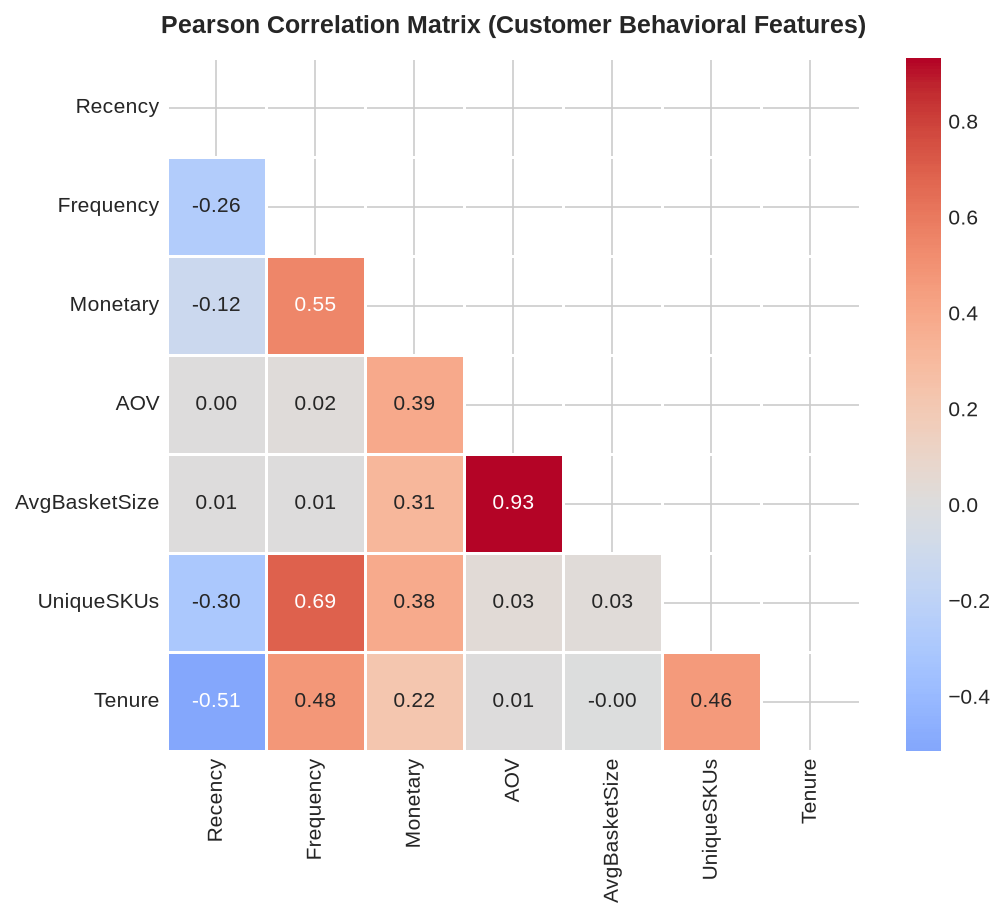

In [6]:
corr = df_cust[CORE_FEATURES].corr()
plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Pearson Correlation Matrix (Customer Behavioral Features)", fontweight="bold", pad=12)
plt.show()


## 9. Determining the Optimal Number of Clusters ($k$)

We evaluate candidate cluster counts from $k=2$ to $k=7$ across four complementary internal validation metrics:
1. **Elbow Method (Inertia / WCSS)**: Within-cluster sum of squares. Inflection points indicate diminishing returns.
2. **Silhouette Score**: Ratio of intra-cluster cohesion to nearest-cluster separation ($-1$ to $+1$).
3. **Calinski-Harabasz Index**: Ratio of between-cluster dispersion to within-cluster dispersion (higher is better).
4. **Davies-Bouldin Index**: Average similarity between each cluster and its most similar counterpart (lower is better).


[EVAL] Evaluating K-Means candidate cluster counts from k=2 to k=7 ...
  k=2: Silhouette=0.3326, Calinski-Harabasz=2623.6, Davies-Bouldin=1.1700, Inertia=18894.6
  k=3: Silhouette=0.2661, Calinski-Harabasz=2021.5, Davies-Bouldin=1.3086, Inertia=15690.7
  k=4: Silhouette=0.2565, Calinski-Harabasz=1937.2, Davies-Bouldin=1.2509, Inertia=12952.8
  k=5: Silhouette=0.2491, Calinski-Harabasz=1763.0, Davies-Bouldin=1.2469, Inertia=11539.6
  k=6: Silhouette=0.2333, Calinski-Harabasz=1609.0, Davies-Bouldin=1.2753, Inertia=10612.2
  k=7: Silhouette=0.2295, Calinski-Harabasz=1512.7, Davies-Bouldin=1.2795, Inertia=9794.0

--- K-Means Candidate Cluster Metrics ---
 k      Inertia  Silhouette  Calinski_Harabasz  Davies_Bouldin
 2 18894.616221    0.332569        2623.643579        1.169955
 3 15690.665967    0.266057        2021.511747        1.308568
 4 12952.819484    0.256456        1937.236375        1.250850
 5 11539.649920    0.249126        1763.040090        1.246890
 6 10612.205805    0.23330

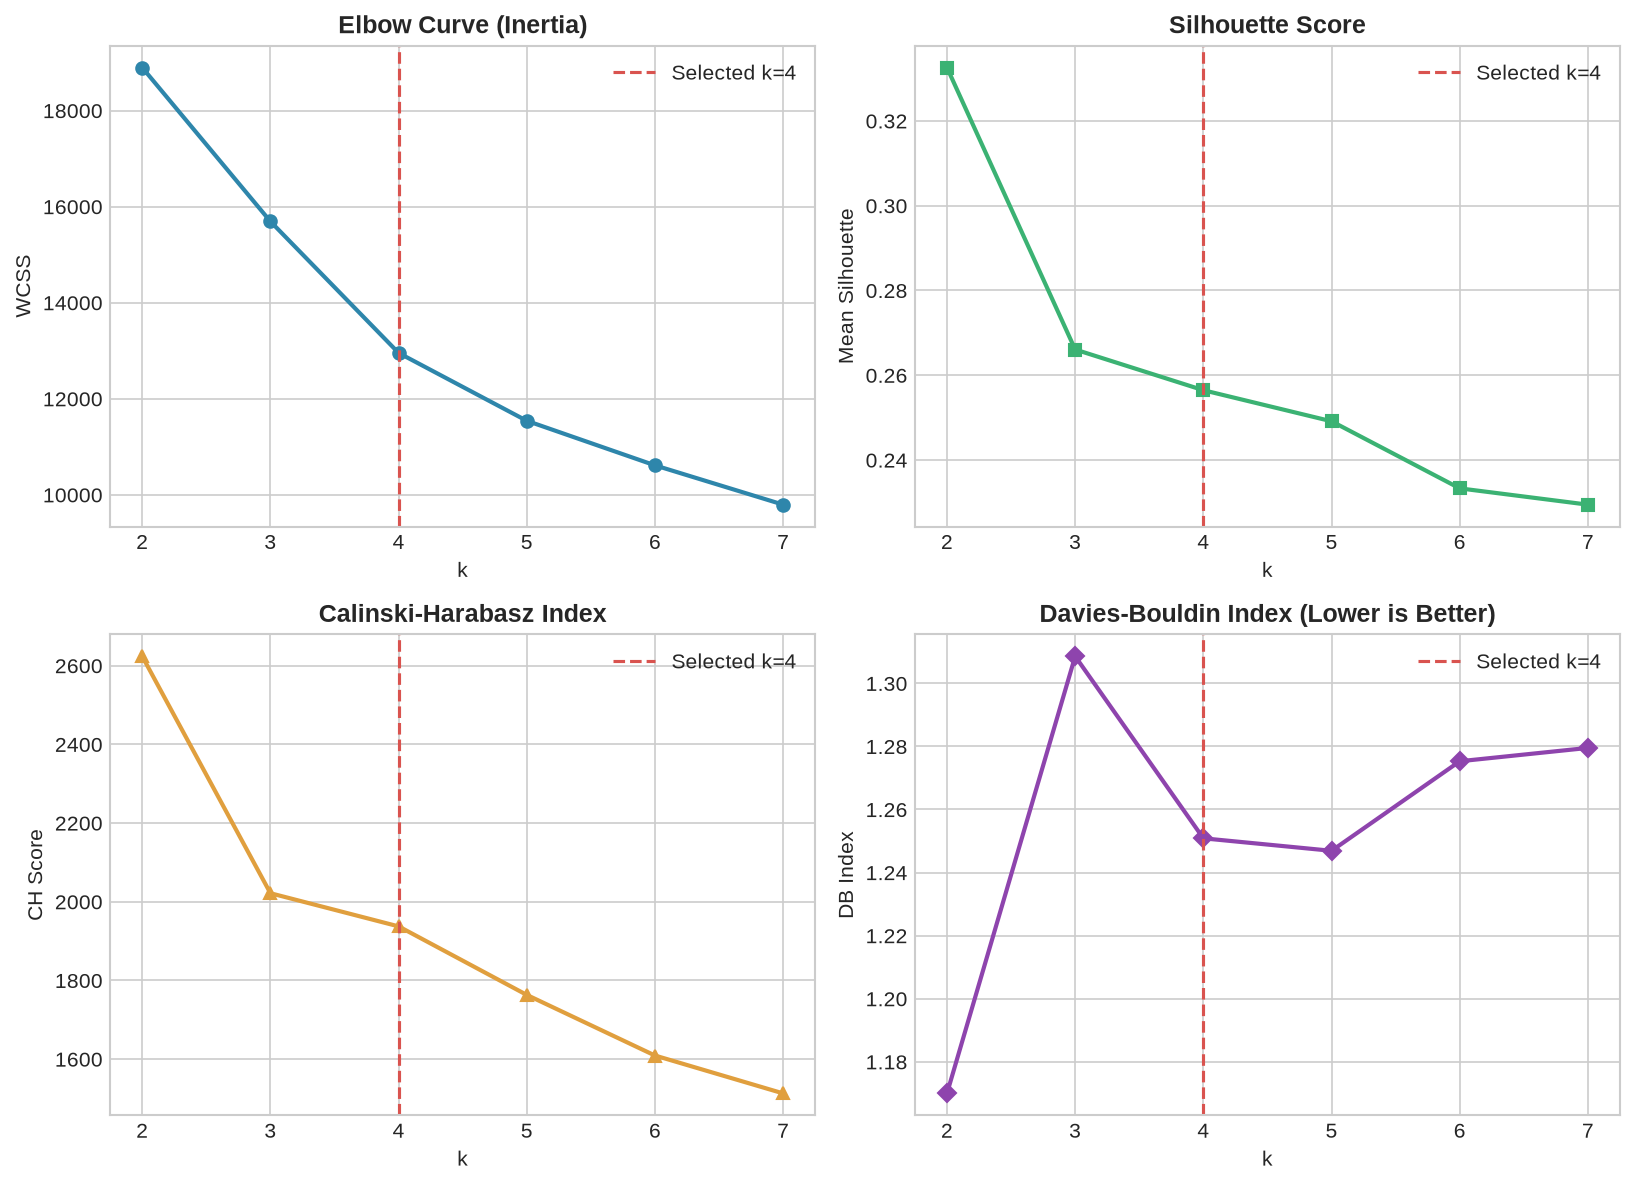

In [7]:
metrics_km = evaluate_cluster_range(X_scaled, k_min=2, k_max=7, random_state=42)
print("\n--- K-Means Candidate Cluster Metrics ---")
print(metrics_km.to_string(index=False))

# Plotting the 4-panel evaluation grid
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes[0, 0].plot(metrics_km['k'], metrics_km['Inertia'], 'o-', color='#2E86AB', lw=2)
axes[0, 0].axvline(4, color='#D9534F', ls='--', label='Selected k=4')
axes[0, 0].set_title("Elbow Curve (Inertia)", fontweight="bold")
axes[0, 0].set_xlabel("k"); axes[0, 0].set_ylabel("WCSS"); axes[0, 0].legend()

axes[0, 1].plot(metrics_km['k'], metrics_km['Silhouette'], 's-', color='#3BB273', lw=2)
axes[0, 1].axvline(4, color='#D9534F', ls='--', label='Selected k=4')
axes[0, 1].set_title("Silhouette Score", fontweight="bold")
axes[0, 1].set_xlabel("k"); axes[0, 1].set_ylabel("Mean Silhouette"); axes[0, 1].legend()

axes[1, 0].plot(metrics_km['k'], metrics_km['Calinski_Harabasz'], '^-', color='#E09F3E', lw=2)
axes[1, 0].axvline(4, color='#D9534F', ls='--', label='Selected k=4')
axes[1, 0].set_title("Calinski-Harabasz Index", fontweight="bold")
axes[1, 0].set_xlabel("k"); axes[1, 0].set_ylabel("CH Score"); axes[1, 0].legend()

axes[1, 1].plot(metrics_km['k'], metrics_km['Davies_Bouldin'], 'D-', color='#8E44AD', lw=2)
axes[1, 1].axvline(4, color='#D9534F', ls='--', label='Selected k=4')
axes[1, 1].set_title("Davies-Bouldin Index (Lower is Better)", fontweight="bold")
axes[1, 1].set_xlabel("k"); axes[1, 1].set_ylabel("DB Index"); axes[1, 1].legend()

plt.tight_layout()
plt.show()


## 10. Agglomerative Hierarchical Clustering & Dendrogram

To examine hierarchical nesting without assuming spherical shapes, we fit Agglomerative Hierarchical Clustering using Ward's minimum variance criterion:
$$\Delta ESS(A, B) = \frac{n_A n_B}{n_A + n_B} ||\mu_A - \mu_B||^2$$


[EVAL] Evaluating Hierarchical Clustering (linkage='ward') from k=2 to k=7 ...
  Hierarchical k=2: Silhouette=0.2793, Calinski-Harabasz=2149.7, Davies-Bouldin=1.2864
  Hierarchical k=3: Silhouette=0.2202, Calinski-Harabasz=1750.1, Davies-Bouldin=1.3978
  Hierarchical k=4: Silhouette=0.2190, Calinski-Harabasz=1523.5, Davies-Bouldin=1.2804
  Hierarchical k=5: Silhouette=0.2081, Calinski-Harabasz=1448.3, Davies-Bouldin=1.3864
  Hierarchical k=6: Silhouette=0.1904, Calinski-Harabasz=1327.3, Davies-Bouldin=1.4063
  Hierarchical k=7: Silhouette=0.1913, Calinski-Harabasz=1251.9, Davies-Bouldin=1.3752

--- Hierarchical Clustering Evaluation ---
 k  Silhouette  Calinski_Harabasz  Davies_Bouldin
 2    0.279328        2149.697505        1.286407
 3    0.220177        1750.100825        1.397799
 4    0.219049        1523.487578        1.280381
 5    0.208116        1448.345152        1.386418
 6    0.190388        1327.261423        1.406276
 7    0.191286        1251.930165        1.375238


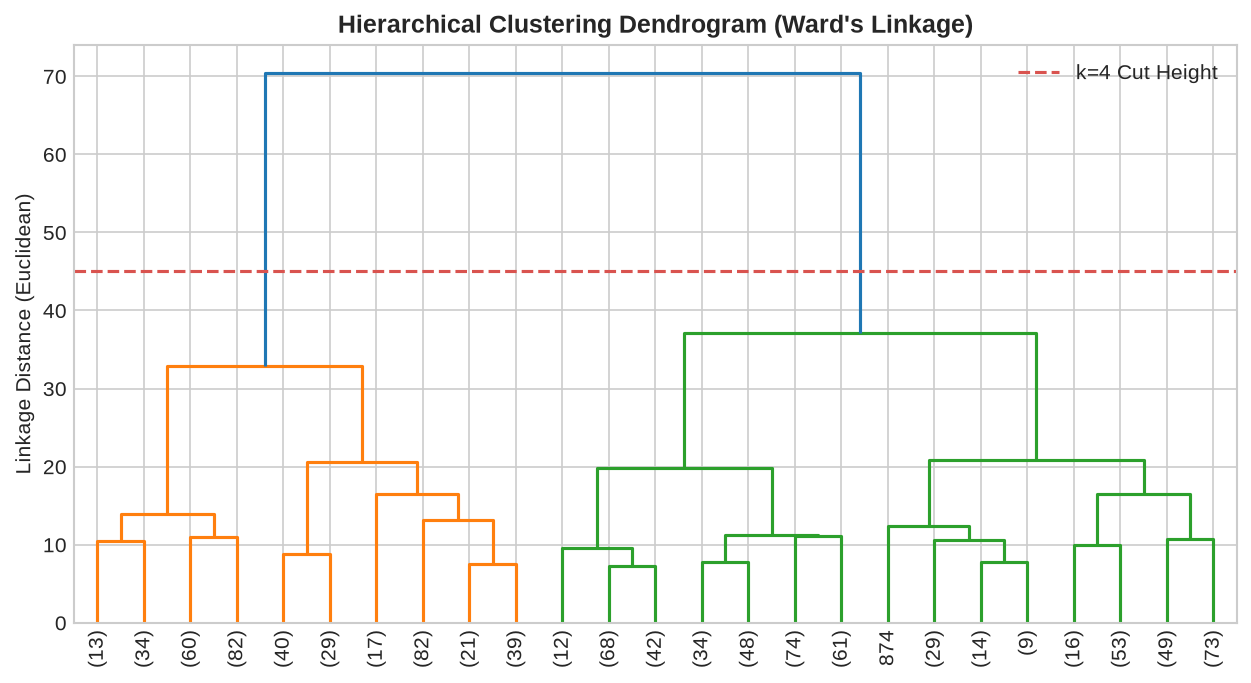

In [8]:
metrics_hc = evaluate_hierarchical_range(X_scaled, k_min=2, k_max=7, linkage_method="ward")
print("\n--- Hierarchical Clustering Evaluation ---")
print(metrics_hc.to_string(index=False))

Z, _ = compute_hierarchical_linkage(X_scaled, sample_size=1000, linkage_method="ward", random_state=42)
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode="lastp", p=25, leaf_rotation=90, color_threshold=45.0)
plt.axhline(45.0, color="#D9534F", linestyle="--", label="k=4 Cut Height")
plt.title("Hierarchical Clustering Dendrogram (Ward's Linkage)", fontweight="bold")
plt.ylabel("Linkage Distance (Euclidean)")
plt.legend()
plt.show()


## 11. Final Model Fitting & Persona Mapping

We fit the final K-Means model with $k=4$ clusters and assign descriptive, data-backed customer personas:
- **Cluster 0**: *Low-Value / Churned Buyers* (Dormant, low spend, single small order)
- **Cluster 1**: *Champions / Power Retailers* (High frequency, high monetary value, high SKU diversity)
- **Cluster 2**: *At-Risk Bulk Buyers* (Single large-volume wholesale order, long recency)
- **Cluster 3**: *Active Regular Customers* (Recent repeat buyers, consistent volume)


In [9]:
km_final, km_labels = train_kmeans(X_scaled, n_clusters=4, random_state=42)
df_cust['Cluster'] = km_labels

PERSONAS = {
    0: "Low-Value / Churned Buyers",
    1: "Champions / Power Retailers",
    2: "At-Risk Bulk Buyers",
    3: "Active Regular Customers"
}
df_cust['Persona'] = df_cust['Cluster'].map(PERSONAS)

# Cluster size summary
sizes = pd.DataFrame({
    'Persona': [PERSONAS[i] for i in range(4)],
    'Customer_Count': df_cust['Cluster'].value_counts().sort_index(),
    'Population_Share_Pct': (df_cust['Cluster'].value_counts(normalize=True).sort_index() * 100).round(2)
})
print("--- Cluster Population Distribution ---")
print(sizes.to_string(index=False))


--- Cluster Population Distribution ---
                    Persona  Customer_Count  Population_Share_Pct
 Low-Value / Churned Buyers             836                 19.29
Champions / Power Retailers            1060                 24.46
        At-Risk Bulk Buyers             951                 21.94
   Active Regular Customers            1487                 34.31


## 12. Cluster Stability & Cross-Algorithm Consensus

We test clustering stability across 10 randomized 80% bootstrap sub-samples using the Adjusted Rand Index (ARI). Furthermore, we compute mutual agreement between K-Means and Hierarchical Clustering.


In [10]:
# Stability Assessment
stability_res = evaluate_stability(X_scaled, n_clusters=4, n_bootstraps=10, sample_fraction=0.8, random_state=42)
print(f"Mean Bootstrap ARI: {stability_res['mean_ari']:.4f} +/- {stability_res['std_ari']:.4f}")

# Cross-Algorithm Consensus
_, hc_labels = train_hierarchical(X_scaled, n_clusters=4, linkage_method="ward")
consensus = compare_algorithms(km_labels, hc_labels)
print(f"Agreement ARI: {consensus['ari']:.4f}, NMI: {consensus['nmi']:.4f}")


[EVAL] Running bootstrap stability test (n_bootstraps=10, fraction=0.8) for k=4...
[EVAL] Stability ARI: Mean=0.9428 +/- 0.0263 (Min=0.9089, Max=0.9848)
Mean Bootstrap ARI: 0.9428 +/- 0.0263
[EVAL] Cross-Algorithm Consensus: Adjusted Rand Index (ARI) = 0.4380, NMI = 0.5517
Agreement ARI: 0.4380, NMI: 0.5517


## 13. Dimensionality Reduction & Cluster Visualization

To visualize the 7-dimensional clustering space, we project observations using:
1. **Principal Component Analysis (PCA)**: Linear projection capturing maximal global variance.
2. **t-SNE (t-Distributed Stochastic Neighbor Embedding)**: Non-linear projection preserving local neighborhood topologies.


PCA Variance Explained: PC1=56.2%, PC2=23.4% (Cumulative: 79.6%)

--- PCA Feature Loadings ---
                 PC1    PC2
Recency       -0.315  0.301
Frequency      0.412 -0.350
Monetary       0.484  0.082
AOV            0.311  0.576
AvgBasketSize  0.301  0.564
UniqueSKUs     0.409 -0.032
Tenure         0.377 -0.360


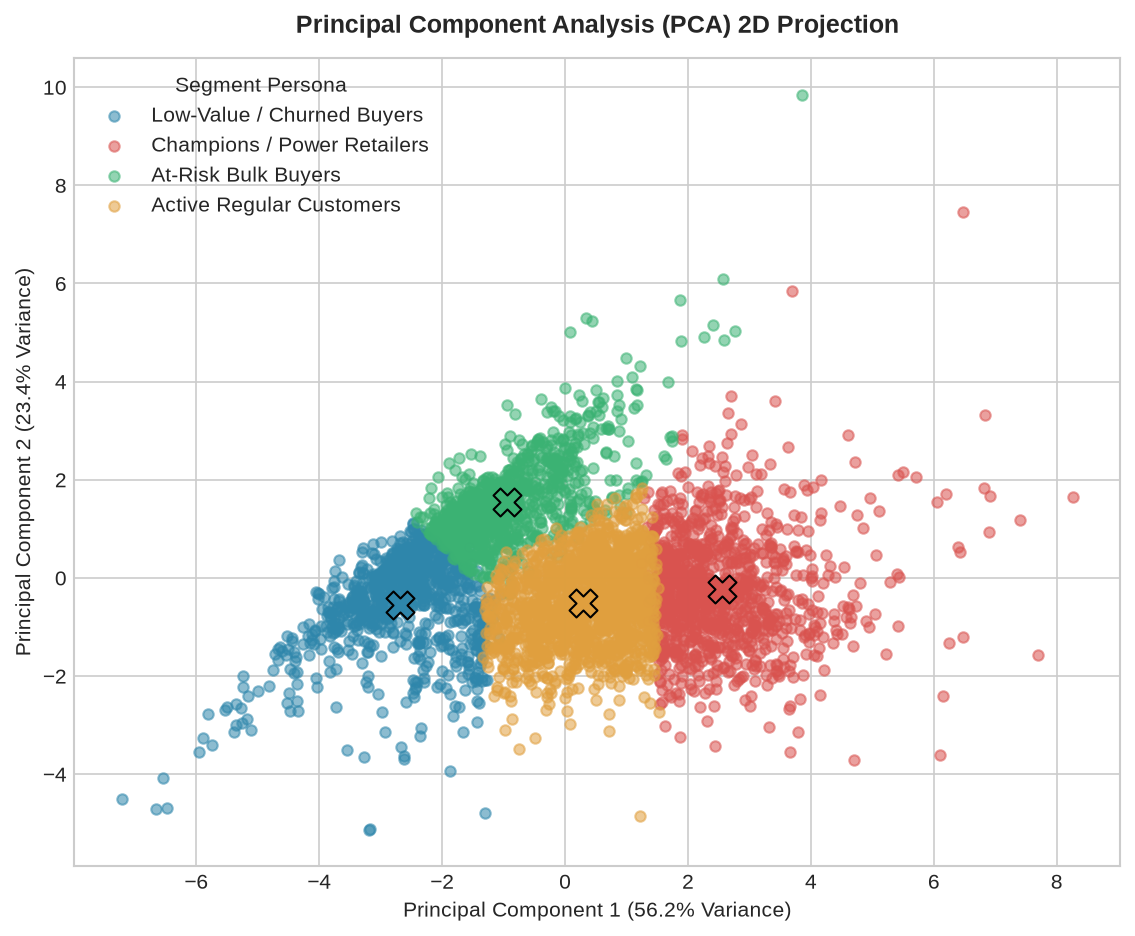

In [11]:
pca_model, X_pca, loadings = compute_pca(X_scaled, n_components=2, feature_names=CORE_FEATURES, random_state=42)
var_pc1 = pca_model.explained_variance_ratio_[0] * 100
var_pc2 = pca_model.explained_variance_ratio_[1] * 100
print(f"PCA Variance Explained: PC1={var_pc1:.1f}%, PC2={var_pc2:.1f}% (Cumulative: {var_pc1+var_pc2:.1f}%)")
print("\n--- PCA Feature Loadings ---")
print(loadings.round(3))

# Plot PCA
plt.figure(figsize=(9, 7))
for i in range(4):
    mask = (km_labels == i)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=25, alpha=0.55, color=PALETTE[i], label=PERSONAS[i])
    plt.scatter(np.mean(X_pca[mask, 0]), np.mean(X_pca[mask, 1]), s=180, color=PALETTE[i], edgecolors="black", marker="X")

plt.title("Principal Component Analysis (PCA) 2D Projection", fontweight="bold", pad=12)
plt.xlabel(f"Principal Component 1 ({var_pc1:.1f}% Variance)")
plt.ylabel(f"Principal Component 2 ({var_pc2:.1f}% Variance)")
plt.legend(title="Segment Persona")
plt.show()


## 14. Comprehensive Cluster Profiling

We calculate unscaled parametric (mean) and non-parametric (median) statistics across each cluster to evaluate exact real-world behavioral differences.


In [12]:
medians_df = df_cust.groupby('Cluster')[CORE_FEATURES].median().round(2)
means_df = df_cust.groupby('Cluster')[CORE_FEATURES].mean().round(2)

total_revenue = df_cust['Monetary'].sum()
cluster_revenue = df_cust.groupby('Cluster')['Monetary'].sum()
revenue_shares = (cluster_revenue / total_revenue * 100).round(2)

profile_table = pd.DataFrame({
    "Persona": [PERSONAS[i] for i in range(4)],
    "Count": df_cust['Cluster'].value_counts().sort_index(),
    "Share_Pct": (df_cust['Cluster'].value_counts(normalize=True).sort_index() * 100).round(2),
    "Revenue_Share_Pct": revenue_shares,
    "Median_Recency_Days": medians_df['Recency'],
    "Median_Frequency_Orders": medians_df['Frequency'],
    "Median_Monetary_GBP": medians_df['Monetary'],
    "Median_AOV_GBP": medians_df['AOV'],
    "Median_Basket_Size": medians_df['AvgBasketSize'],
    "Median_Unique_SKUs": medians_df['UniqueSKUs'],
    "Median_Tenure_Days": medians_df['Tenure']
})
print("--- Detailed Customer Profile Summary ---")
print(profile_table.to_string(index=False))


--- Detailed Customer Profile Summary ---
                    Persona  Count  Share_Pct  Revenue_Share_Pct  Median_Recency_Days  Median_Frequency_Orders  Median_Monetary_GBP  Median_AOV_GBP  Median_Basket_Size  Median_Unique_SKUs  Median_Tenure_Days
 Low-Value / Churned Buyers    836      19.29               1.59                165.5                      1.0               152.13          128.67               65.00                 9.0                 0.0
Champions / Power Retailers   1060      24.46              75.99                 14.0                      7.0              2979.97          428.52              259.88               111.0               293.0
        At-Risk Bulk Buyers    951      21.94               7.78                106.0                      1.0               391.98          375.00              238.00                23.0                 0.0
   Active Regular Customers   1487      34.31              14.65                 43.0                      3.0               7

## 15. Economic Contribution Analysis

A key finding is the dramatic economic disparity across segments, demonstrating the classic Pareto principle (80/20 rule) in commercial retail.


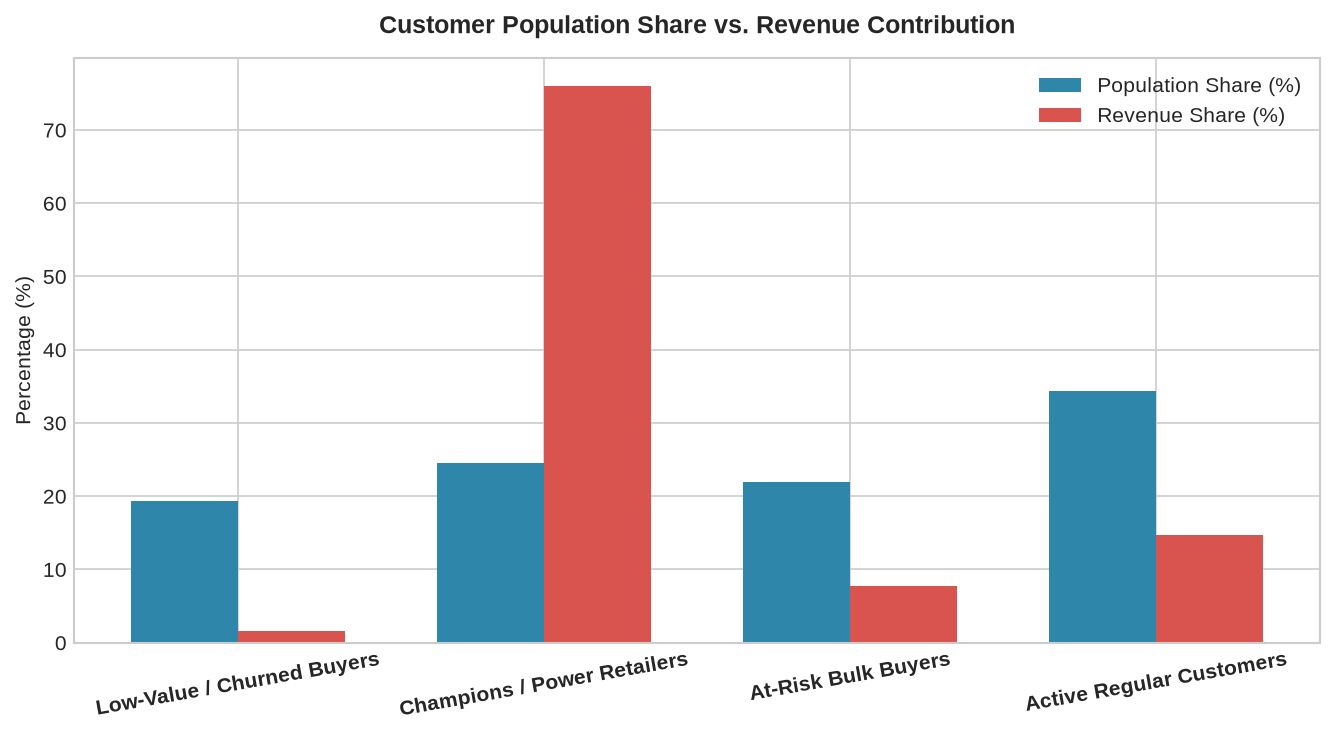

In [13]:
counts = df_cust['Cluster'].value_counts().sort_index()
pop_pct = (counts / len(df_cust) * 100).values
rev_pct = revenue_shares.values
labels = [PERSONAS[i] for i in range(4)]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, pop_pct, width, label='Population Share (%)', color='#2E86AB')
plt.bar(x + width/2, rev_pct, width, label='Revenue Share (%)', color='#D9534F')
plt.xticks(x, labels, rotation=10, fontweight="bold")
plt.ylabel("Percentage (%)")
plt.title("Customer Population Share vs. Revenue Contribution", fontweight="bold", pad=12)
plt.legend()
plt.tight_layout()
plt.show()


## 16. Business & Strategic Implications

Based on the quantitative profiles of the four clusters, we formulate targeted marketing and operational strategies:

### 1. Champions / Power Retailers (Cluster 1: 24.5% Customers, 76.0% Revenue)
- **Profile**: Median spend £2,980, median 7 orders, 111 unique SKUs, active within 14 days.
- **Strategic Focus**: Dedicated account management, tier-one VIP loyalty rewards, bulk pricing tiers, and early access to new wholesale product lines.
- **Risk Mitigation**: Churn in this segment represents catastrophic revenue loss. Implement automated alert monitors triggered if recency exceeds 45 days.

### 2. Active Regular Customers (Cluster 3: 34.3% Customers, 14.7% Revenue)
- **Profile**: Median spend £752, median 3 orders, 41 SKUs, recency 43 days, tenure 177 days.
- **Strategic Focus**: Cross-selling and basket expansion. Offer category bundles, personalized product recommendations, and free-shipping thresholds above £250.

### 3. At-Risk Bulk Buyers (Cluster 2: 21.9% Customers, 7.8% Revenue)
- **Profile**: High basket size (median 238 items), moderate spend (£392), but only 1 order, dormant for 106 days.
- **Strategic Focus**: Re-engagement and replenishment campaigns. Seasonal promotions aligned with seasonal gifting cycles.

### 4. Low-Value / Churned Shoppers (Cluster 0: 19.3% Customers, 1.6% Revenue)
- **Profile**: Minimal spend (£152), 9 unique items, dormant for 165 days.
- **Strategic Focus**: Automated, low-cost win-back emails with steep discount codes. Limit high-cost marketing touches.


## 17. Analytical Limitations & Methodological Caveats

1. **Absence of Demographic Context**: The dataset lacks demographic or firmographic data (e.g. consumer vs corporate buyer, geography, age, revenue). All classifications reflect behavioral transaction logs only.
2. **Non-Causal Relationship**: Clustering identifies statistical associations and geometric proximity in feature space; it does not prove causal mechanisms behind customer purchases or churn.
3. **Snapshot Truncation**: Customer history is observed over approximately one calendar year (Dec 2010 to Dec 2011). Long-term seasonal cycles (multi-year holiday patterns) cannot be fully isolated.
4. **Euclidean Geometry Assumption**: K-Means assumes convex, isotropic cluster geometries. While log transformations normalize feature variances, non-spherical structures may be slightly compromised.


## 18. Conclusion & Future Directions

This project has demonstrated an end-to-end unsupervised learning solution for customer segmentation:
- Preprocessed 541k transactions and extracted 4,334 customer behavioral profiles.
- Stabilized severe right-skewed distributions through mathematical log transformations.
- Justified a 4-cluster K-Means topology using Inertia, Silhouette, Calinski-Harabasz, Davies-Bouldin, and bootstrap stability testing (ARI = 0.9428).
- Discovered that 24.5% of customers generate 76.0% of total revenue.
- Developed pragmatic marketing interventions to optimize customer lifetime value.

**Future Extensions**:
- Implementing RFM time-series transition matrices (Markov chains) to predict customer migration between clusters over time.
- Applying semi-supervised clustering if historical customer lifetime value labels become available.
- Deploying batch clustering inference pipelines in cloud data warehouses (e.g., BigQuery / Snowflake).
